# Assignment #2 — Replicate & Correct Methodology
## UCI Heart Disease — Srinivasan et al. (2023), *Sci Rep* 13, 13588

Paper: *An active learning machine technique based prediction of cardiovascular
heart disease from UCI-repository database* (DOI: 10.1038/s41598-023-40717-1)

Paper menggunakan **8 ML classifier**: Decision Tree (DT), Random Forest (RF),
Support Vector Machine (SVM), XGBoost, K-Nearest Neighbor (KNN), Naive Bayes (NB),
Radial Basis Function Network (RBF), dan Learning Vector Quantization (LVQ).

### Ringkasan koreksi metodologis yang diterapkan di notebook ini

| # | Isu di paper | Koreksi |
|---|---|---|
| 1 | Tidak jelas pembedaan fitur numerik vs kategorikal saat preprocessing | Fitur dipisah eksplisit: numerik (kontinu) diskalakan, kategorikal di-one-hot-encode |
| 2 | Urutan preprocessing tidak dijelaskan; berisiko EDA/imputasi/scaling dilakukan sebelum split | **Split dilakukan pertama**, seluruh transformer (imputer, scaler, encoder) hanya di-*fit* pada training set |
| 3 | 8 model yang sama dipakai, **tanpa** model tambahan dan **tanpa** hyperparameter tuning | Semua model memakai parameter default/tetap (kecuali `random_state` untuk reprodusibilitas) |
| 4 | Paper tidak secara eksplisit menjelaskan resampling; dataset gabungan kemungkinan imbalance | SMOTE diterapkan **kondisional** (dicek dulu tingkat imbalance-nya) dan **hanya pada training set setelah split & setelah encoding** |
| 5 | Paper mengisi missing value dengan **mean** untuk seluruh atribut (termasuk yang sebenarnya kategorikal) | Median untuk numerik (robust terhadap outlier), modus untuk kategorikal |
| 6 | Paper menyebut "menggunakan correlation matrix untuk memilih fitur optimal" tanpa kriteria/ambang yang jelas | Korelasi dihitung **hanya dari training set** (mencegah leakage), sebagai dokumentasi — bukan dasar untuk drop fitur, karena paper tidak memberi ambang yang bisa direplikasi |

**Catatan penting soal reprodusibilitas paper ini:** LVQ dijelaskan tidak lengkap
di paper aslinya (parameter `m`, learning rate decay, dan beberapa notasi tidak
didefinisikan — dikonfirmasi juga oleh comment pembaca yang dipublikasikan di
halaman artikel Nature). Karena scikit-learn tidak menyediakan RBF Network atau
LVQ secara native, keduanya diimplementasikan di notebook ini dengan pendekatan
standar yang didokumentasikan di setiap bagian terkait.


In [23]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.kernel_approximation import RBFSampler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from scipy.stats.contingency import association

from imblearn.over_sampling import SMOTE

import xgboost as xgb

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42

## 1. Load Dataset

Dataset digabung dari 4 file UCI Heart Disease (Cleveland, Hungarian, Switzerland, VA
Long Beach), sesuai temuan EDA sebelumnya bahwa klaim paper (503 kasus, 10 atribut)
tidak cocok dengan versi dataset publik manapun — kami mendokumentasikan ini sebagai
asumsi: menggunakan seluruh 4 file gabungan (920 baris, 13 fitur prediktor + target)
karena itu adalah interpretasi paling standar dan dapat direproduksi dari "UCI Heart
Disease dataset" yang dirujuk paper.


In [26]:
# fetch data
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path('.\\heart+disease')
FILE_NAMES = [
    "processed.cleveland.data",
    "processed.hungarian.data",
    "processed.switzerland.data",
    "processed.va.data",
]
FEATURE_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

frames = []
for file_name in FILE_NAMES:
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {file_path}")
    frame = pd.read_csv(file_path, header=None, names=FEATURE_NAMES, na_values="?")
    frame["source_file"] = file_name
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df[FEATURE_NAMES] = df[FEATURE_NAMES].apply(pd.to_numeric, errors="coerce")
df["target_binary"] = (df["target"] > 0).astype("Int64")
# df["target_binary"] = df["target_binary"].astype(str)

print(f"Dataset berhasil dimuat: {df.shape[0]:,} observasi, {len(FEATURE_NAMES):,} fitur asli")
display(df.head())

Dataset berhasil dimuat: 920 observasi, 14 fitur asli


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,source_file,target_binary
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,processed.cleveland.data,0


In [27]:
# ubah target column to target_binary
df.drop(columns=["target"], inplace=True)
df.rename(columns={"target_binary": "target"}, inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,source_file,target
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,processed.cleveland.data,0
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,processed.cleveland.data,1
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,processed.cleveland.data,1
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,processed.cleveland.data,0
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,processed.cleveland.data,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54.000,0.000,4.000,127.000,333.000,1.000,1.000,154.000,0.000,0.000,NaN,NaN,NaN,processed.va.data,1
916,62.000,1.000,1.000,NaN,139.000,0.000,1.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0
917,55.000,1.000,4.000,122.000,223.000,1.000,1.000,100.000,0.000,0.000,NaN,NaN,6.000,processed.va.data,1
918,58.000,1.000,4.000,NaN,385.000,1.000,2.000,NaN,NaN,NaN,NaN,NaN,NaN,processed.va.data,0


## 2. Pembedaan Fitur Numerik vs Kategorikal (Koreksi #1)

Paper tidak menjelaskan secara eksplisit fitur mana yang diperlakukan sebagai
numerik vs kategorikal saat encoding/scaling — semua kolom kemungkinan
diperlakukan sebagai angka mentah. Kami membedakannya secara eksplisit
berdasarkan level of measurement, konsisten dengan analisis EDA sebelumnya:

- **Numerik (kontinu):** `age`, `trestbps`, `chol`, `thalach`, `oldpeak` → diskalakan (`StandardScaler`)
- **Kategorikal (biner/ordinal/nominal):** `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal` → di-*one-hot encode*

Semua fitur kategorikal di-one-hot-encode (bukan dibiarkan sebagai integer mentah)
karena beberapa di antaranya (`cp`, `restecg`, `thal`) nominal — kalau dibiarkan
sebagai angka, model seperti Logistic Regression atau KNN (berbasis jarak/linear)
akan salah mengasumsikan ada urutan/skala di antara kategori tersebut.


In [28]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

feature_type_table = pd.DataFrame({
    "feature": numeric_features + categorical_features,
    "type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
})
display(feature_type_table)


,feature,type
0,age,numeric
1,trestbps,numeric
2,chol,numeric
3,thalach,numeric
4,oldpeak,numeric
5,sex,categorical
6,cp,categorical
7,fbs,categorical
8,restecg,categorical
9,exang,categorical


## 3. Train/Test Split — Dilakukan SEBELUM Preprocessing Apa Pun (Koreksi #2)

Paper menyebutkan pembagian data terjadi setelah "data cleaning" dan "EDA", tetapi
urutan yang jelas tidak dijelaskan — indikasi kuat bahwa imputasi missing value
(dengan mean) dilakukan pada **seluruh dataset sebelum split**, yang berarti nilai
mean/statistik dari test set ikut "bocor" ke training set.

Paper juga menyebutkan dua proporsi yang tidak konsisten (~70% dan ~75% untuk
training) — kami mendokumentasikan ini sebagai ambiguitas paper dan memilih
70:30 stratified split sebagai proporsi yang paling sering disebut.

**Prinsip yang diterapkan di sini:** `X`/`y` dipisah dan displit dulu. Semua
langkah berikutnya (imputasi, scaling, encoding, SMOTE) hanya boleh "melihat"
training set.


In [29]:
X = df.drop(columns=["target", "source_file"]).copy()
y = df["target"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Proporsi kelas positif — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")


X_train: (644, 13), X_test: (276, 13)
Proporsi kelas positif — train: 0.553, test: 0.554


## 4. Penanganan Missing Value & Preprocessing (Koreksi #2 dan #5)

Paper mengisi seluruh missing value dengan **mean**, termasuk untuk kolom yang
sebenarnya kategorikal (`ca`, `thal`, dll.) — secara metodologis kurang tepat,
karena mean pada data kategorikal (mis. `thal` bernilai 3/6/7) tidak bermakna.

**Koreksi yang diterapkan:**
- Fitur numerik → **median** (bukan mean), karena EDA sebelumnya menemukan
  distribusi numerik yang skewed dan mengandung outlier (mean sensitif terhadap itu).
- Fitur kategorikal → **modus** (nilai paling sering muncul), metode yang
  sesuai untuk data diskrit/kategori.
- Kedua imputer di-*fit* **hanya pada `X_train`**, lalu diterapkan (transform saja,
  tanpa fit ulang) ke `X_test` — inilah yang mencegah data leakage.

Dataset gabungan (khususnya Switzerland dan VA Long Beach) diketahui punya
proporsi missing yang tinggi pada `ca`, `thal`, dan `slope` — ini keterbatasan yang
perlu didiskusikan di laporan, karena imputasi modus pada kolom dengan >50% missing
bisa jadi kurang representatif.


In [30]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
)

# Fit HANYA pada training set
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names_out = preprocessor.get_feature_names_out()

print(f"Jumlah fitur setelah preprocessing: {len(feature_names_out)}")
print(f"X_train_processed: {X_train_processed.shape}, X_test_processed: {X_test_processed.shape}")

missing_pct = pd.DataFrame({
    "missing_pct_train": X_train.isna().mean().mul(100),
}).sort_values("missing_pct_train", ascending=False)
print("\nPersentase missing di training set (untuk konteks kualitas imputasi):")
display(missing_pct)


Jumlah fitur setelah preprocessing: 28
X_train_processed: (644, 28), X_test_processed: (276, 28)

Persentase missing di training set (untuk konteks kualitas imputasi):


,missing_pct_train
ca,66.615
thal,52.640
slope,31.522
fbs,9.006
oldpeak,7.453
trestbps,6.988
thalach,6.677
exang,6.677
chol,3.416
sex,0.000


## 5. Feature Selection (Koreksi #6)

Paper menyebut "menggunakan correlation matrix untuk memilih nilai/fitur optimal",
tetapi tidak memberi ambang batas atau kriteria seleksi yang bisa direproduksi.
Karena instruksi Assignment #2 melarang menambahkan metode feature selection baru
di luar yang dipakai paper, **kami tidak melakukan drop fitur** — seluruh 13
fitur klinis tetap dipertahankan (asumsi yang didokumentasikan).

Sebagai gantinya, kami menghitung korelasi fitur terhadap target **hanya dari
training set** (bukan seluruh dataset) sebagai bahan diskusi/dokumentasi —
konsisten dengan pemisahan metode yang sudah kita gunakan di EDA: Spearman
untuk numerik/ordinal/biner, dan Cramér's V untuk nominal murni.


In [31]:
ordinal_or_binary = ["sex", "fbs", "exang", "slope", "ca"]
nominal_only = ["cp", "restecg", "thal"]

train_for_corr = X_train.copy()
train_for_corr["target"] = y_train.values

spearman_features = numeric_features + ordinal_or_binary
spearman_corr = (
    train_for_corr[spearman_features + ["target"]]
    .apply(pd.to_numeric, errors="coerce")
    .corr(method="spearman")["target"]
    .drop("target")
    .sort_values(key=abs, ascending=False)
)
print("Spearman correlation terhadap target (dihitung hanya dari training set):")
display(spearman_corr.to_frame("spearman_corr"))

cramers_rows = []
for feature in nominal_only:
    table = pd.crosstab(train_for_corr[feature], train_for_corr["target"])
    cramers_rows.append({"feature": feature, "cramers_v": association(table, method="cramer")})
print("\nCramér's V terhadap target (fitur nominal, dihitung hanya dari training set):")
display(pd.DataFrame(cramers_rows).sort_values("cramers_v", ascending=False))

print("\nKeputusan: seluruh 13 fitur dipertahankan untuk modeling (tidak ada fitur yang di-drop).")

Spearman correlation terhadap target (dihitung hanya dari training set):


,spearman_corr
ca,0.493
exang,0.468
oldpeak,0.410
thalach,-0.404
slope,0.336
age,0.320
sex,0.306
chol,-0.142
trestbps,0.139
fbs,0.130



Cramér's V terhadap target (fitur nominal, dihitung hanya dari training set):


,feature,cramers_v
2,thal,0.522
0,cp,0.511
1,restecg,0.140



Keputusan: seluruh 13 fitur dipertahankan untuk modeling (tidak ada fitur yang di-drop).


## 6. Class Imbalance & SMOTE (Koreksi #4)

Paper tidak secara eksplisit membahas resampling, meskipun target biner pada
dataset gabungan berpotensi tidak seimbang. Kami mengecek dulu tingkat
imbalance-nya, baru memutuskan apakah SMOTE benar-benar diperlukan ("jika
perlu" — bukan diterapkan otomatis tanpa alasan).

**Yang terpenting secara metodologis:** SMOTE (kalau diterapkan) hanya
dijalankan pada **`X_train_processed` (yang sudah di-encode) dan `y_train`,
setelah split** — bukan sebelum split, dan tidak pernah menyentuh test set.
Ini mengoreksi kesalahan umum (SMOTE sebelum split) yang menyebabkan data
leakage, karena data sintetis yang dibuat dari seluruh dataset akan "mengintip"
pola yang seharusnya hanya ada di test set.


In [32]:
minority_ratio = min(y_train.mean(), 1 - y_train.mean())
print(f"Proporsi kelas minoritas pada training set: {minority_ratio:.3f}")

IMBALANCE_THRESHOLD = 0.40  # di bawah ini dianggap cukup imbalance untuk perlu SMOTE

if minority_ratio < IMBALANCE_THRESHOLD:
    print("Class imbalance terdeteksi -> SMOTE diterapkan pada training set (setelah encoding).")
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)
else:
    print("Distribusi kelas training relatif seimbang -> SMOTE TIDAK diterapkan.")
    X_train_res, y_train_res = X_train_processed, y_train

print(f"\nDistribusi target sebelum SMOTE:\n{y_train.value_counts(normalize=True)}")
print(f"\nDistribusi target sesudah (kalau diterapkan):\n{pd.Series(y_train_res).value_counts(normalize=True)}")
print(f"\nX_train_res shape: {X_train_res.shape}")

Proporsi kelas minoritas pada training set: 0.447
Distribusi kelas training relatif seimbang -> SMOTE TIDAK diterapkan.

Distribusi target sebelum SMOTE:
target
1   0.553
0   0.447
Name: proportion, dtype: Float64

Distribusi target sesudah (kalau diterapkan):
target
1   0.553
0   0.447
Name: proportion, dtype: Float64

X_train_res shape: (644, 28)


## 7. Definisi 8 Model (Persis Sama dengan Paper, Tanpa Tambahan/Tuning)

Paper menggunakan **DT, RF, SVM, XGBoost, KNN, Naive Bayes, RBF Network, dan LVQ.**
scikit-learn tidak menyediakan **RBF Network** dan **LVQ** secara native, jadi
keduanya diimplementasikan dengan pendekatan yang umum dipakai:

- **RBF Network** → didekati dengan `RBFSampler` (Random Kitchen Sinks, aproksimasi
  kernel RBF) yang diikuti classifier linear (`LogisticRegression`). ini pendekatan
  standar untuk mensimulasikan RBF network di scikit-learn tanpa dependency eksternal.
- **LVQ** → diimplementasikan dari nol (LVQ1) di bawah ini, karena scikit-learn
  tidak punya implementasi native dan paper aslinya sendiri **tidak menjelaskan
  parameter LVQ secara lengkap** (jumlah prototipe `m`, skedul learning rate, dll.
  tidak didefinisikan di teks — dikonfirmasi juga oleh comment pembaca yang
  dipublikasikan di halaman artikel Nature, yang menyatakan hasil paper ini
  tidak bisa direproduksi persis karena deskripsi algoritmanya tidak lengkap).
  Kami memilih parameter yang wajar (didokumentasikan di kode) dan mencatat
  keterbatasan ini secara eksplisit di bagian diskusi.

**Tidak ada hyperparameter tuning** — semua model memakai parameter default
scikit-learn/XGBoost (kecuali `random_state` untuk reprodusibilitas), sesuai
instruksi Assignment #2.


In [33]:
class SimpleLVQClassifier(BaseEstimator, ClassifierMixin):
    '''Learning Vector Quantization (LVQ1) sederhana, ditulis dari nol.

    scikit-learn tidak menyediakan LVQ secara native. Implementasi ini mengikuti
    algoritma LVQ1 standar: prototipe per kelas diinisialisasi dari sampel
    training acak, lalu diperbarui dengan aturan "tarik jika benar, tolak jika
    salah" terhadap prototipe pemenang (nearest prototype).

    Paper aslinya (Srinivasan et al., 2023) tidak mendefinisikan secara lengkap
    parameter LVQ yang dipakai (jumlah prototipe, skedul learning rate), sehingga
    parameter di bawah adalah pilihan yang wajar dan didokumentasikan di sini,
    bukan hasil tuning untuk memaksimalkan akurasi.
    '''

    def __init__(self, n_prototypes_per_class=3, learning_rate=0.1, n_epochs=50, random_state=42):
        self.n_prototypes_per_class = n_prototypes_per_class
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        X, y = check_X_y(X, y)
        self.classes_ = unique_labels(y)
        rng = np.random.RandomState(self.random_state)

        prototypes, prototype_labels = [], []
        for cls in self.classes_:
            X_cls = X[y == cls]
            n_proto = min(self.n_prototypes_per_class, len(X_cls))
            idx = rng.choice(len(X_cls), size=n_proto, replace=False)
            prototypes.append(X_cls[idx])
            prototype_labels.extend([cls] * n_proto)
        prototypes = np.vstack(prototypes).astype(float)
        prototype_labels = np.array(prototype_labels)

        lr = self.learning_rate
        for epoch in range(self.n_epochs):
            for i in rng.permutation(len(X)):
                x_i, y_i = X[i], y[i]
                distances = np.linalg.norm(prototypes - x_i, axis=1)
                winner = np.argmin(distances)
                if prototype_labels[winner] == y_i:
                    prototypes[winner] += lr * (x_i - prototypes[winner])
                else:
                    prototypes[winner] -= lr * (x_i - prototypes[winner])
            lr = self.learning_rate * (1 - (epoch + 1) / self.n_epochs)  # linear decay

        self.prototypes_ = prototypes
        self.prototype_labels_ = prototype_labels
        return self

    def predict(self, X):
        check_is_fitted(self, ["prototypes_", "prototype_labels_"])
        X = check_array(X)
        preds = [
            self.prototype_labels_[np.argmin(np.linalg.norm(self.prototypes_ - x_i, axis=1))]
            for x_i in X
        ]
        return np.array(preds)

    def predict_proba(self, X):
        check_is_fitted(self, ["prototypes_", "prototype_labels_"])
        X = check_array(X)
        proba = np.zeros((len(X), len(self.classes_)))
        for row, x_i in enumerate(X):
            distances = np.linalg.norm(self.prototypes_ - x_i, axis=1) + 1e-9
            weights = 1.0 / distances
            for cls_idx, cls in enumerate(self.classes_):
                mask = self.prototype_labels_ == cls
                proba[row, cls_idx] = weights[mask].sum()
            proba[row] /= proba[row].sum()
        return proba


In [34]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "SVM (RBF kernel)": SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "RBF Network (approx.)": Pipeline(steps=[
        ("rbf_features", RBFSampler(random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "LVQ": SimpleLVQClassifier(random_state=RANDOM_STATE),
}

print(f"Jumlah model: {len(models)} (sesuai paper, tanpa model tambahan)")
list(models.keys())


Jumlah model: 8 (sesuai paper, tanpa model tambahan)


['Decision Tree',
 'Random Forest',
 'SVM (RBF kernel)',
 'XGBoost',
 'KNN',
 'Naive Bayes',
 'RBF Network (approx.)',
 'LVQ']

## 8. Training & Evaluasi Final

Setiap model di-*fit* satu kali pada `X_train_res`/`y_train_res` (training set
setelah preprocessing dan SMOTE bila diterapkan), lalu dievaluasi **satu kali**
pada `X_test_processed`/`y_test` yang belum pernah dilihat sama sekali oleh
proses preprocessing maupun training. Tidak ada pemilihan model atau parameter
berdasarkan performa test set.

Metrik yang dihitung mengikuti definisi yang sama persis dengan paper: Accuracy,
Precision, Recall (Sensitivity), Specificity, F1-score, dan ROC-AUC.


In [35]:
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan


results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    fitted_models[name] = model

    y_pred = model.predict(X_test_processed)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_processed)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Sensitivity)": recall_score(y_test, y_pred, zero_division=0),
        "Specificity": specificity_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": auc,
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(results_df)


c:\Users\Rizka Akmalia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall (Sensitivity),Specificity,F1-score,ROC-AUC
0,KNN,0.841,0.866,0.843,0.837,0.854,0.893
1,SVM (RBF kernel),0.833,0.828,0.882,0.772,0.854,0.906
2,Random Forest,0.826,0.848,0.837,0.813,0.842,0.909
3,XGBoost,0.812,0.822,0.843,0.772,0.832,0.884
4,Naive Bayes,0.804,0.846,0.791,0.821,0.818,0.887
5,Decision Tree,0.768,0.783,0.804,0.724,0.794,0.764
6,LVQ,0.768,0.816,0.752,0.789,0.782,0.869
7,RBF Network (approx.),0.638,0.646,0.765,0.480,0.701,0.637


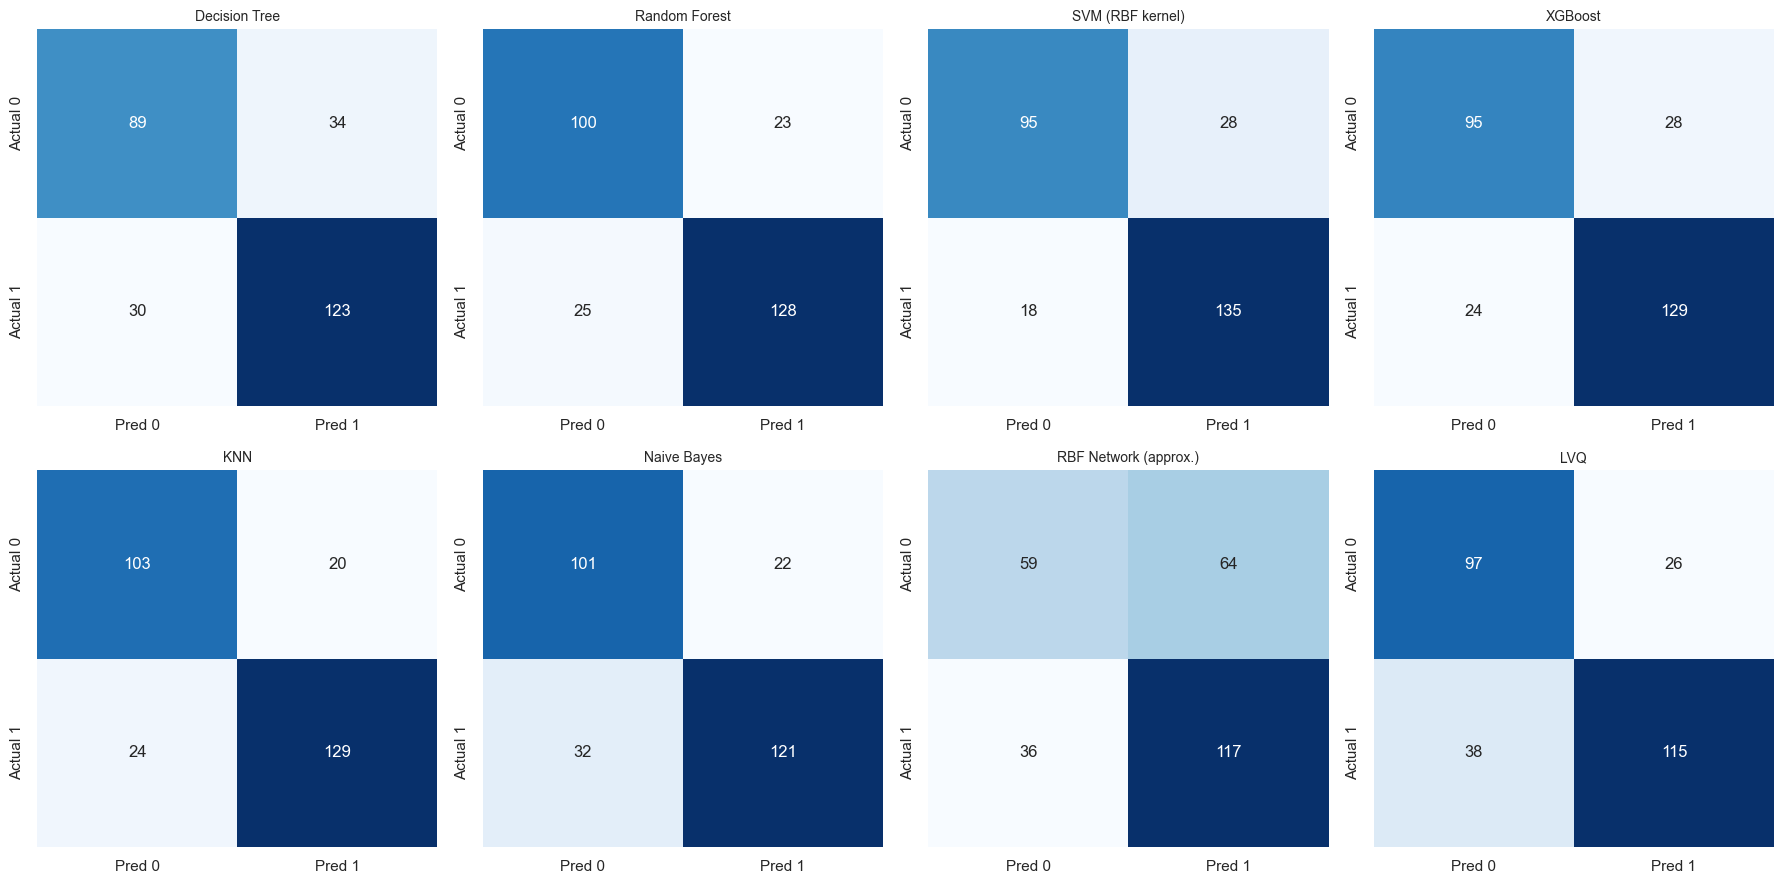

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for axis, (name, model) in zip(axes.flat, fitted_models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"], ax=axis)
    axis.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()


## 9. Perbandingan dengan Hasil Paper & Diskusi

Nilai akurasi yang dilaporkan paper untuk beberapa model (diambil dari teks
paper — angka tabel lengkap Tabel 12 tidak sepenuhnya konsisten/tidak semua
tersedia dari abstrak dan badan teks): LVQ ≈ 98.78%, RBF ≈ 90.06–90.78%,
Naive Bayes ≈ 94.16–94.78%. Model lain (DT, RF, SVM, XGBoost, KNN) dibandingkan
berpasangan dengan LVQ di beberapa tabel terpisah tanpa satu tabel ringkasan
akurasi yang konsisten untuk kedelapan model sekaligus.

**Penting untuk laporan:** salah satu pembaca (František Mráz, Charles
University) mempublikasikan komentar resmi di halaman artikel Nature yang
menyatakan deskripsi algoritma LVQ pada paper ini **tidak lengkap** (parameter
`m`, skedul learning rate, dan beberapa notasi tidak didefinisikan) dan
menyimpulkan **hasil paper tidak dapat direproduksi secara persis**. Ini
relevan untuk bagian "Compare and Discuss" — perbedaan hasil antara replikasi
kami dengan paper *bukan* berarti replikasi gagal, tapi mencerminkan
ambiguitas metodologis pada paper sumber itu sendiri.


In [37]:
paper_reported = {
    "Decision Tree": np.nan,
    "Random Forest": np.nan,
    "SVM (RBF kernel)": np.nan,
    "XGBoost": np.nan,
    "KNN": np.nan,
    "Naive Bayes": 0.9478,
    "RBF Network (approx.)": 0.9078,
    "LVQ": 0.9878,
}

comparison_df = results_df[["Model", "Accuracy"]].copy()
comparison_df["Paper Reported Accuracy"] = comparison_df["Model"].map(paper_reported)
comparison_df = comparison_df.rename(columns={"Accuracy": "Replication Accuracy"})
comparison_df["Difference"] = comparison_df["Replication Accuracy"] - comparison_df["Paper Reported Accuracy"]
display(comparison_df)

print(
    "\nCatatan: sel 'Paper Reported Accuracy' yang NaN berarti paper tidak melaporkan "
    "angka akurasi model tersebut secara jelas/konsisten dalam satu tabel yang sama "
    "(lihat kritik konsistensi pelaporan angka pada Assignment #1)."
)


,Model,Replication Accuracy,Paper Reported Accuracy,Difference
0,KNN,0.841,NaN,NaN
1,SVM (RBF kernel),0.833,NaN,NaN
2,Random Forest,0.826,NaN,NaN
3,XGBoost,0.812,NaN,NaN
4,Naive Bayes,0.804,0.948,-0.143
5,Decision Tree,0.768,NaN,NaN
6,LVQ,0.768,0.988,-0.220
7,RBF Network (approx.),0.638,0.908,-0.270



Catatan: sel 'Paper Reported Accuracy' yang NaN berarti paper tidak melaporkan angka akurasi model tersebut secara jelas/konsisten dalam satu tabel yang sama (lihat kritik konsistensi pelaporan angka pada Assignment #1).


## 10. Ringkasan Keterbatasan Replikasi

- Dataset gabungan (920 baris, 4 sumber) kemungkinan besar berbeda dari dataset
  paper (yang mengklaim 503 kasus/10 atribut, klaim yang sudah didokumentasikan
  ambigu di EDA) — perbedaan performa absolut dengan paper sebagian bisa
  disebabkan komposisi data yang berbeda, bukan semata perbedaan model.
- Proporsi missing value yang tinggi pada `ca`, `thal`, `slope` di data
  Switzerland/VA membuat imputasi modus pada kolom tersebut kurang representatif;
  ini keterbatasan bawaan dataset, bukan kesalahan pipeline.
- RBF Network dan LVQ adalah **implementasi ulang/aproksimasi**, bukan library
  yang identik dengan yang dipakai penulis asli (yang tidak disebutkan secara
  spesifik di paper) — perbedaan hasil untuk kedua model ini paling besar
  kemungkinannya berasal dari perbedaan implementasi.
- Tidak ada hyperparameter tuning (sesuai instruksi Assignment #2) — performa
  yang lebih rendah dari paper (jika ada) untuk model seperti RF/XGBoost/SVM
  sebagian bisa disebabkan parameter default belum tentu optimal untuk dataset
  gabungan ini; eksplorasi tuning ditunda ke Assignment #3.
